In [ ]:
pip install torch torchvision matplotlib opencv-python


In [4]:
import kagglehub
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
import pandas as pd
import matplotlib.image as mpimg
import os
from PIL import Image

In [2]:
# Download latest version
path = kagglehub.dataset_download("lokisilvres/dental-disease-panoramic-detection-dataset")

print("Path to dataset files:", path)

100%|██████████| 2.37G/2.37G [00:28<00:00, 89.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lokisilvres/dental-disease-panoramic-detection-dataset/versions/6


In [5]:

# Ruta del dataset descargado
dataset_path = '/root/.cache/kaggle/datasets/lokisilvres/dental-disease-panoramic-detection-dataset/'

# Contar cuántos archivos de imágenes hay
image_files = [f for f in os.listdir(dataset_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
print(f"Total de imágenes en el dataset: {len(image_files)}")


FileNotFoundError: [Errno 2] No such file or directory: '/root/.cache/kaggle/datasets/lokisilvres/dental-disease-panoramic-detection-dataset/'

lo de abajo fue la primera prueba


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

DATASET_DIR = "/content/drive/MyDrive/Panoramic_Dental_Xray_Dataset"

print("¿Existe la carpeta?", os.path.isdir(DATASET_DIR))
print("Archivos encontrados:", len(os.listdir(DATASET_DIR)))
print("Ejemplo:", os.listdir(DATASET_DIR)[:10])



¿Existe la carpeta? True
Archivos encontrados: 107
Ejemplo: ['30.jpg', '2.jpg', '25.jpg', '28.jpg', '11.jpg', '8.jpg', '17.jpg', '31.jpg', '1.jpg', '16.jpg']


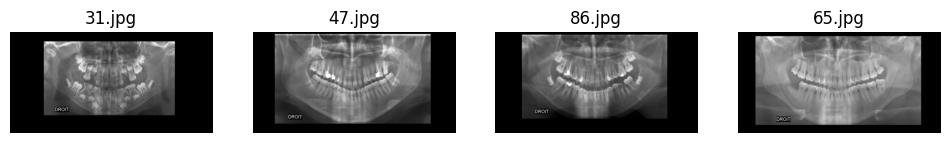

In [ ]:
import cv2
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import numpy as np
from PIL import Image

class DentalXrayDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_files = [f for f in os.listdir(root_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        self.transform = transform

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert("L")  # gris
        if self.transform:
            image = self.transform(image)
        return image, self.image_files[idx]

# Transformaciones
transform = transforms.Compose([
    transforms.Resize((256, 512)),  # ajustar tamaño
    transforms.ToTensor()
])

# Dataset y DataLoader
dataset = DentalXrayDataset(DATASET_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

# Mostrar un batch
images, names = next(iter(dataloader))

plt.figure(figsize=(12,6))
for i in range(len(images)):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i].squeeze(0), cmap="gray")
    plt.title(names[i])
    plt.axis("off")
plt.show()



tercera prueba

In [15]:
!pip -q install ultralytics>=8.2.0
from ultralytics import YOLO
import os, glob


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [6]:
dataset_path = '/content/drive/My Drive/el candidato/YOLO/YOLO/train/images'


In [7]:
DATASET_DIR = "/content/drive/My Drive/el candidato/YOLO/YOLO/train/images"

print("¿Existe la carpeta?", os.path.isdir(DATASET_DIR))
print("Archivos encontrados:", len(os.listdir(DATASET_DIR)))
print("Ejemplo:", os.listdir(DATASET_DIR)[:10])


¿Existe la carpeta? True
Archivos encontrados: 9481
Ejemplo: ['cropped_BARANPREET-SINGH_2023-10-26184623_1_png.rf.003298e522d7b35ea8c2169dd2be3fa3.jpg', 'bcb4a583-MOHAMADY_GHAZALEH_2020-06-28114052_jpg.rf.969dff1f05c2d91d4f0808e5cf2f8f1d.jpg', 'bc2dd43c-Fallahi_Golamreza_2022-06-12141808_jpg.rf.2e90aac1f03ee51eac650288138d8e35.jpg', 'c875a366-Hasankavyari_Shokofeh_2022-06-12140720_jpg.rf.b77c4cdef7af723cc8777c84717ebc38.jpg', 'cropped_ARASHDEEP-KAUR_2023-10-21141001_1_png.rf.e9bd209c29611da33d6b11288da11245.jpg', 'cropped_GURWANT-SINGH_2023-10-20191813_1_png.rf.583ef8e71482cd1a70fb47f68700ee63.jpg', 'c9b78aa3-LOTFI_PARIA_2020-05-18184452_jpg.rf.91ed539bcae4088ed1bf206921418520.jpg', 'b99b3517-Fath_abadi_boz_cheloee_Fateme_46yo_31052021_155111_jpg.rf.590c1e9e72979749c96a19b499f54e38.jpg', 'b5ce49f2-Esmaeilnejd_Aminolah_38yo_01062021_170344_jpg.rf.f0db29c8ebbb18001ed15157847c5f45.jpg', 'beb52c34-Panahi_Mahnaz_2022-06-12142606_jpg.rf.57cdf2faa751a569d647a9b72fb32027.jpg']


In [5]:
from google.colab import drive
drive.mount('/content/drive')

# Ajusta estas rutas a tu carpeta en Drive
ROOT = "/content/drive/My Drive/el_candidato/YOLO/YOLO"
TRAIN_IMG = f"{ROOT}/train/images"
VAL_IMG   = f"{ROOT}/valid/images"
TEST_IMG  = f"{ROOT}/test/images"   # si tu test está en /test/images
DATA_YAML = f"{ROOT}/data.yaml"     # ubicaremos aquí un yaml "limpio" para Colab



Mounted at /content/drive


In [14]:
names = [
  "Caries","Crown","Filling","Implant","Malaligned","Mandibular Canal","Missing teeth",
  "Periapical lesion","Retained root","Root Canal Treatment","Root Piece","impacted tooth",
  "maxillary sinus","Bone Loss","Fracture teeth","Permanent Teeth","Supra Eruption","TAD",
  "abutment","attrition","bone defect","gingival former","metal band","orthodontic brackets",
  "permanent retainer","post - core","plating","wire","Cyst","Root resorption","Primary teeth"
]

yaml_text = f"""# Auto-generado para Colab
train: {TRAIN_IMG}
val:   {VAL_IMG}
test:  {TEST_IMG}

names:
""" + "\n".join([f"  {i}: {n}" for i,n in enumerate(names)])

with open(DATA_YAML, "w") as f:
    f.write(yaml_text)

print(open(DATA_YAML).read())


# Auto-generado para Colab
train: /content/drive/My Drive/el candidato/YOLO/YOLO/train/images
val:   /content/drive/My Drive/el candidato/YOLO/YOLO/valid/images
test:  /content/drive/My Drive/el candidato/YOLO/YOLO/test/images

names:
  0: Caries
  1: Crown
  2: Filling
  3: Implant
  4: Malaligned
  5: Mandibular Canal
  6: Missing teeth
  7: Periapical lesion
  8: Retained root
  9: Root Canal Treatment
  10: Root Piece
  11: impacted tooth
  12: maxillary sinus
  13: Bone Loss
  14: Fracture teeth
  15: Permanent Teeth
  16: Supra Eruption
  17: TAD
  18: abutment
  19: attrition
  20: bone defect
  21: gingival former
  22: metal band
  23: orthodontic brackets
  24: permanent retainer
  25: post - core
  26: plating
  27: wire
  28: Cyst
  29: Root resorption
  30: Primary teeth


In [16]:
import random

def quick_audit(img_dir):
    imgs = glob.glob(os.path.join(img_dir, "*.jpg")) + \
           glob.glob(os.path.join(img_dir, "*.jpeg")) + \
           glob.glob(os.path.join(img_dir, "*.png"))
    print("Total imágenes:", len(imgs))
    # Buscar una etiqueta correspondiente
    sample = random.choice(imgs)
    stem = os.path.splitext(os.path.basename(sample))[0]
    lbl  = os.path.join(os.path.dirname(img_dir).replace("images","labels"), stem + ".txt")
    print("Ejemplo imagen:", sample)
    print("Etiqueta:", lbl, "-> existe:", os.path.exists(lbl))
    if os.path.exists(lbl):
        with open(lbl) as f:
            lines = [ln.strip() for ln in f if ln.strip()]
        if lines:
            parts = lines[0].split()
            print("Primera línea etiqueta:", lines[0][:120], "...")
            print("Número de valores en 1ª línea:", len(parts))
            if len(parts) > 5:
                print("▶ Detectado formato SEGMENTACIÓN (polígonos YOLO).")
            elif len(parts) == 5:
                print("▶ Detectado formato DETECCIÓN (caja x,y,w,h).")
            else:
                print("⚠ Formato inesperado, revisa ese .txt")

quick_audit(TRAIN_IMG)


Total imágenes: 9481
Ejemplo imagen: /content/drive/My Drive/el candidato/YOLO/YOLO/train/images/c0ab16ba-Khalatbary_Mohammad_hasan_29y_01062021_093748_jpg.rf.f17811a8a56490709856e0acb25f9ddb.jpg
Etiqueta: /content/drive/My Drive/el candidato/YOLO/YOLO/train/c0ab16ba-Khalatbary_Mohammad_hasan_29y_01062021_093748_jpg.rf.f17811a8a56490709856e0acb25f9ddb.txt -> existe: False


In [1]:
import torch, os
print(torch.cuda.is_available(), torch.cuda.device_count(), os.environ.get("CUDA_VISIBLE_DEVICES"))


True 1 None


In [2]:
# 1) Instala Ultralytics (si no lo tienes)
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 47.7 MB/s eta 0:00:00


In [12]:
import os, glob

ROOT = "/content/drive/MyDrive/el_candidato/YOLO/YOLO"
KEEP_MAP = {0:0, 11:1, 13:2}  # old_id -> new_id

for split in ["train","valid","test"]:
    in_dir = f"{ROOT}/{split}/labels"
    out_dir = f"{ROOT}/{split}/labels_3cls"
    os.makedirs(out_dir, exist_ok=True)

    for f in glob.glob(os.path.join(in_dir, "*.txt")):
        new_lines=[]
        with open(f, "r") as fh:
            for line in fh:
                toks = line.strip().split()
                if not toks:
                    continue
                old = int(float(toks[0]))
                if old in KEEP_MAP:
                    toks[0] = str(KEEP_MAP[old])  # reasignar id a 0,1,2
                    new_lines.append(" ".join(toks))
        if new_lines:
            with open(os.path.join(out_dir, os.path.basename(f)), "w") as oh:
                oh.write("\n".join(new_lines) + "\n")



In [13]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
model.train(
    data="/content/drive/MyDrive/el_candidato/YOLO/YOLO/nuevodata.yaml",
    epochs=50, imgsz=640, batch=16, workers=2, device=0
)


Se han truncado las últimas 5000 líneas del flujo de salida.
train: /content/drive/MyDrive/el_candidato/YOLO/YOLO/train/images/4169850000_jpg.rf.bd6e16235b3cec1a7244f42598c5dfff.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/drive/MyDrive/el_candidato/YOLO/YOLO/train/images/4169900000_jpg.rf.08b4bdf86ce5774f2437867a83eb96ca.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/drive/MyDrive/el_candidato/YOLO/YOLO/train/images/4169900000_jpg.rf.357902dc992ec147e1b32f2a69e01425.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/drive/MyDrive/el_candidato/YOLO/YOLO/train/images/4169900000_jpg.rf.f00c648d1c9cf71c985f6aa04b366f2b.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 3. Possible class labels are 0-2
train: /content/drive/MyDri

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7897a71de300>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04